# Task 1: Image Enhancement

### a) Visualize the initial image and the corresponding histogram.


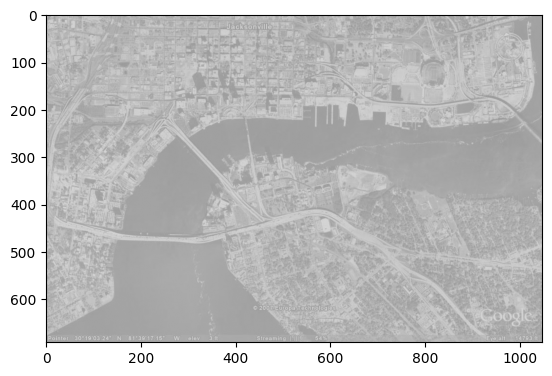

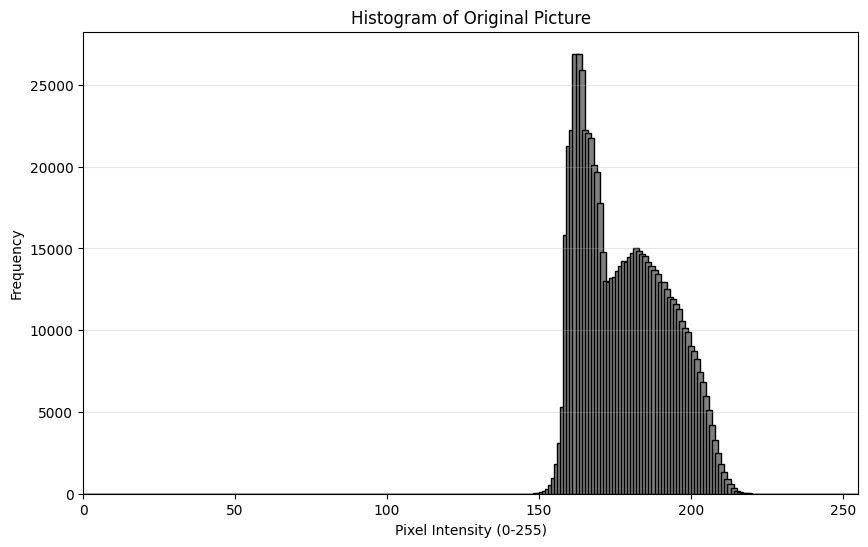

In [47]:
from utils import *
from PIL import Image
import matplotlib.pyplot as plt
plt.close('all')

img = Image.open("../input_sat_image.jpg")
img_array = np.array(img)
greyscale = rgb2gray(img_array)
plt.imshow(greyscale, cmap='gray', vmin=0, vmax=255)

def draw_histogram(image_array, title='Histogram'):
    hist, bin_edges = np.histogram(image_array.flatten(), bins=256, range=(0, 256))
    plt.figure(figsize=(10, 6))
    plt.bar(bin_edges[:-1], hist, width=2, color='gray', edgecolor='black')
    plt.xlim(0, 255)
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

draw_histogram(greyscale,'Histogram of Original Picture')




### b) Describe the characteristics of the histogram.
The histogram of the greyscale image shows the distribution of pixel intensities. We can see that the pixel intensities are clustered around the higher end of the intensity range, which indicates that the image is relatively bright. Since the values are close to each other and are clustered, it indicates that the image has low contrast, as there isn't much variation in pixel intensity.

### c) Enhance the image using contrast stretching.

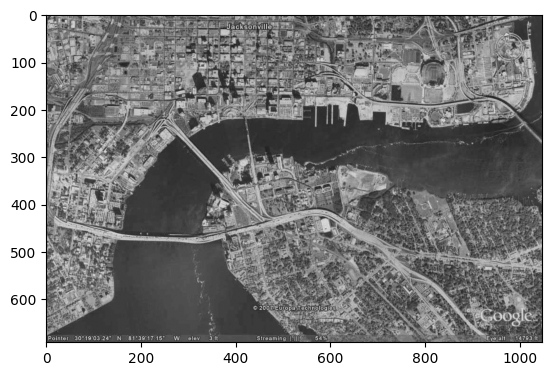

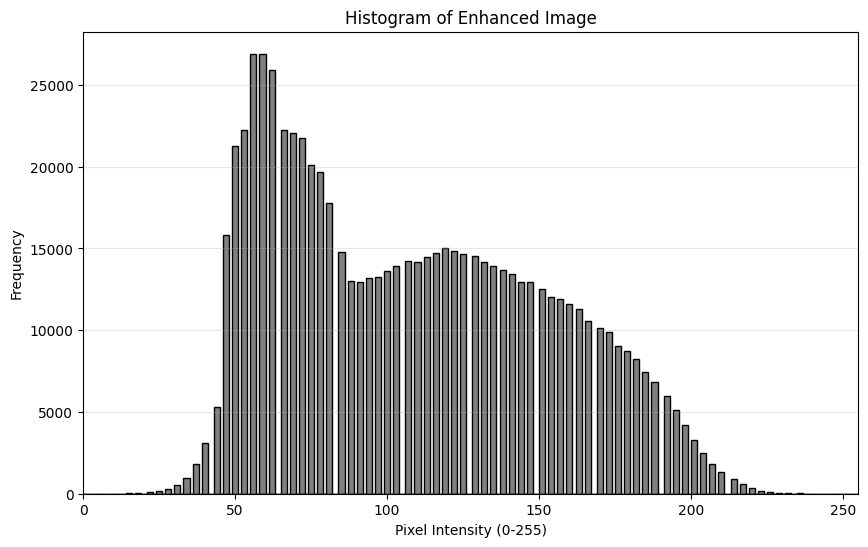

In [48]:
def contrast_stretching(image):
    min_pixel = np.min(image)
    max_pixel = np.max(image)
    stretched_image = (image - min_pixel) * (255 / (max_pixel - min_pixel))
    return stretched_image.astype(np.uint8)

enhanced_image = contrast_stretching(greyscale)
plt.imshow(enhanced_image, cmap='gray', vmin=0, vmax=255)
draw_histogram(enhanced_image, 'Histogram of Enhanced Image')

### d) Shortly describe the differences to the initial histogram.
The pixel values are now more spread across the entire intensity range, which indicates that the contrast of the image has been improved. Along with the brighter pixels, there are now more darker pixels as well, which adds more contrast.

# Task 2 - Binarization
### Write a function for thresholding the enhanced image of Task 1)

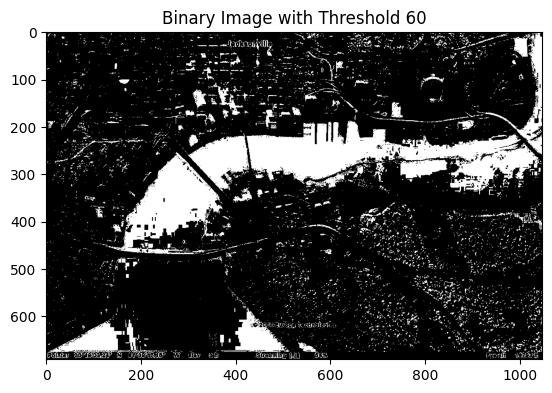

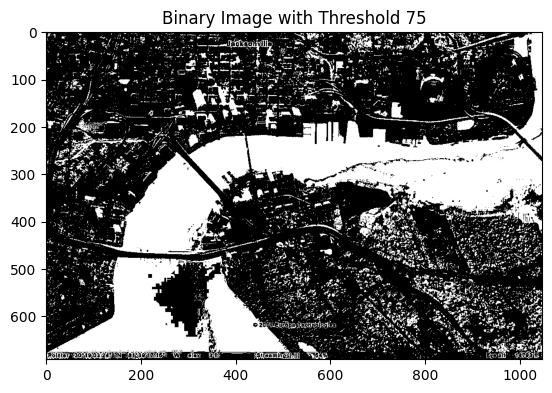

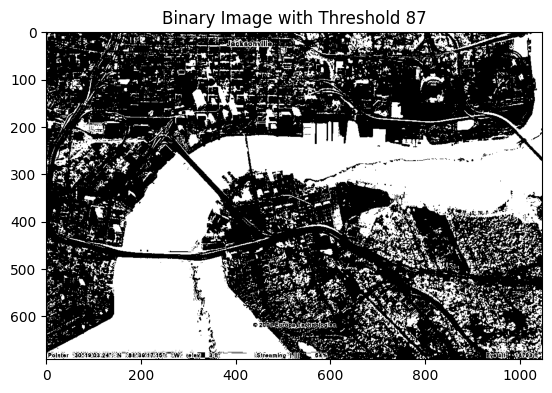

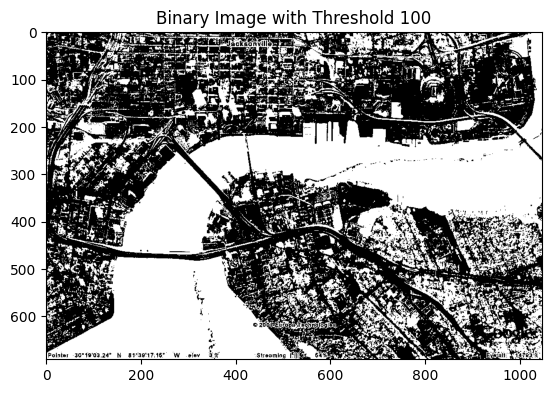

In [49]:
def thresholding(image, threshold):
    binary_image = np.where(image > threshold, 0, 1)
    return binary_image.astype(np.uint8)

for threshold in [60, 75, 87, 100]:
    binary_image = thresholding(enhanced_image, threshold)
    plt.imshow(binary_image, cmap='gray', vmin=0, vmax=1)
    plt.title(f'Binary Image with Threshold {threshold}')
    plt.show()

### c) Test a number of different threshold values and describe the effects. Did you experience any difficulties while searching for an appropriate threshold value?
When looking at the histogram of the enhanced image, it becomes relatively easy to find an approximate value for a suited threshold. Around the 75 pixel intensity mark, one can see a separation between the many dark pixels and the following brighter pixels, since before that value, there is a big spike of dark pixels. When testing that value, one can see in the image, that quite a big part of the lower water surface is still considered background, which can be improved by correcting the value upwards a little, e.g. to 87, which produces a pretty good binary mask which singles out the water surfaces. When increasing the value further, e.g. to 100, the mask begins to show more of the land mass as foreground as well, which is not desired. Since some streets and buildings in the original picture are similarly dark as the water surface, it will be hard to separate them, which in turn makes it hard to find an accurate threshold value.

# Task 3 - Morphological Operators
### Write a function for morphological filtering of the binary mask obtained in Task 2)

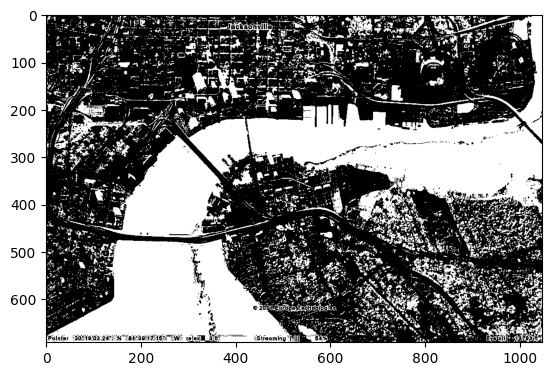

[0 1]


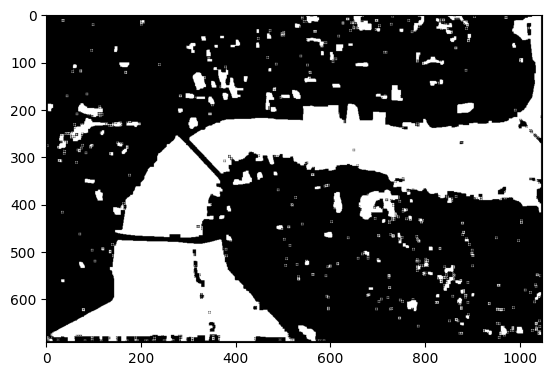

In [65]:
def morphological_filtering(mask, struct_el):
    filtered_mask = imopen(mask, struct_el)
    filtered_mask = imclose(filtered_mask, struct_el)
    return filtered_mask.astype(np.uint8)

binary_mask_87 = thresholding(enhanced_image, 87)
plt.imshow(binary_mask_87, cmap='gray', vmin=0, vmax=1)
plt.show()
print(np.unique(binary_mask_87))
#struct_el = np.array([[1, 0, 1], [0,0,0], [1,0,1]])
struct_el = np.array([
    [1,1,0,1,1], 
    [1,0,0,0,1], 
    [0,0,0,0,0],
    [1,0,0,0,1], 
    [1,1,0,1,1]
])


filtered_mask = morphological_filtering(binary_mask_87, struct_el)
plt.imshow(filtered_mask, cmap='gray', vmin=0, vmax=1)
plt.show()
